In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle

In [2]:
train_df = pd.read_csv('data/채널정보_with_segment.csv')
train_df

,기준년월,ID,인입횟수_ARS_R6M,이용메뉴건수_ARS_R6M,인입일수_ARS_R6M,인입월수_ARS_R6M,인입후경과월_ARS,인입횟수_ARS_B0M,이용메뉴건수_ARS_B0M,인입일수_ARS_B0M,...,당사PAY_방문월수_R6M,당사멤버쉽_방문횟수_B0M,당사멤버쉽_방문횟수_R6M,당사멤버쉽_방문월수_R6M,OS구분코드,홈페이지_금융건수_R6M,홈페이지_선결제건수_R6M,홈페이지_금융건수_R3M,홈페이지_선결제건수_R3M,Segment
0,201807,TRAIN_000000,10회 이상,10회 이상,8,6,0,2,6,2,...,0,22,221,6,Android,0,0,0,0,D
1,201807,TRAIN_000001,1회 이상,1회 이상,0,0,0,0,0,0,...,0,0,0,0,NaN,0,0,0,0,E
2,201807,TRAIN_000002,1회 이상,1회 이상,1,1,0,2,5,1,...,0,0,0,0,Android,11,6,5,5,C
3,201807,TRAIN_000003,10회 이상,10회 이상,10,6,0,2,6,2,...,0,23,219,6,Android,0,0,0,0,D
4,201807,TRAIN_000004,1회 이상,1회 이상,0,0,0,0,0,0,...,0,0,0,0,Android,0,0,0,0,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,201812,TRAIN_399995,1회 이상,1회 이상,0,0,0,0,0,0,...,0,0,0,0,NaN,0,0,0,0,E
2399996,201812,TRAIN_399996,1회 이상,1회 이상,0,0,0,0,0,0,...,0,0,0,1,NaN,0,0,0,0,D
2399997,201812,TRAIN_399997,1회 이상,1회 이상,0,0,0,0,0,0,...,0,0,0,0,NaN,0,0,0,0,C
2399998,201812,TRAIN_399998,1회 이상,1회 이상,0,0,0,0,0,0,...,0,0,0,0,NaN,0,0,0,0,E


In [3]:
# 데이터 프레임 정보 확인
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400000 entries, 0 to 2399999
Columns: 106 entries, 기준년월 to Segment
dtypes: int64(98), object(8)
memory usage: 1.9+ GB


In [4]:
# 결측치 확인
train_df.isna().sum()

기준년월              0
ID                0
인입횟수_ARS_R6M      0
이용메뉴건수_ARS_R6M    0
인입일수_ARS_R6M      0
                 ..
홈페이지_금융건수_R6M     0
홈페이지_선결제건수_R6M    0
홈페이지_금융건수_R3M     0
홈페이지_선결제건수_R3M    0
Segment           0
Length: 106, dtype: int64

### 불만제기후경과월_R12M	
- 불만제기후 경과월 (과거12개월간)	int64	12, 0

In [6]:
train_df['불만제기후경과월_R12M'].value_counts()

불만제기후경과월_R12M
12    1313922
0     1086078
Name: count, dtype: int64

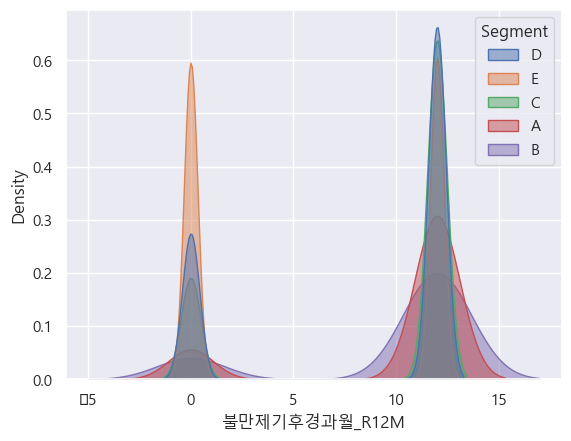

In [7]:
sns.kdeplot(
    data=train_df,
    x='불만제기후경과월_R12M',
    hue='Segment',
    fill=True,
    common_norm=False,
    alpha=0.5
)
plt.show()

In [8]:
subset = train_df[train_df['기준년월'] == 201811]

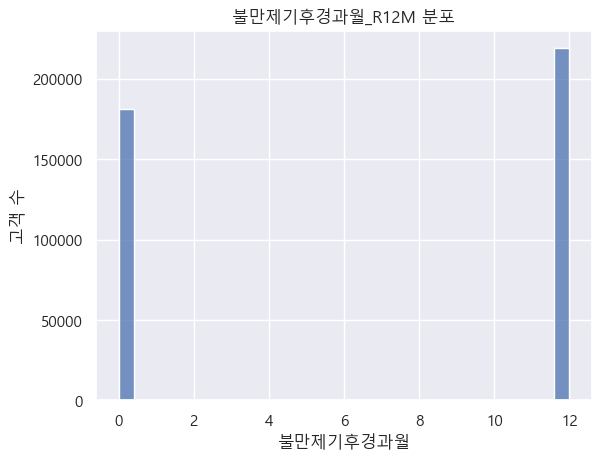

In [9]:
sns.histplot(subset['불만제기후경과월_R12M'], bins=30)
plt.title('불만제기후경과월_R12M 분포')
plt.xlabel('불만제기후경과월')
plt.ylabel('고객 수')
plt.show()

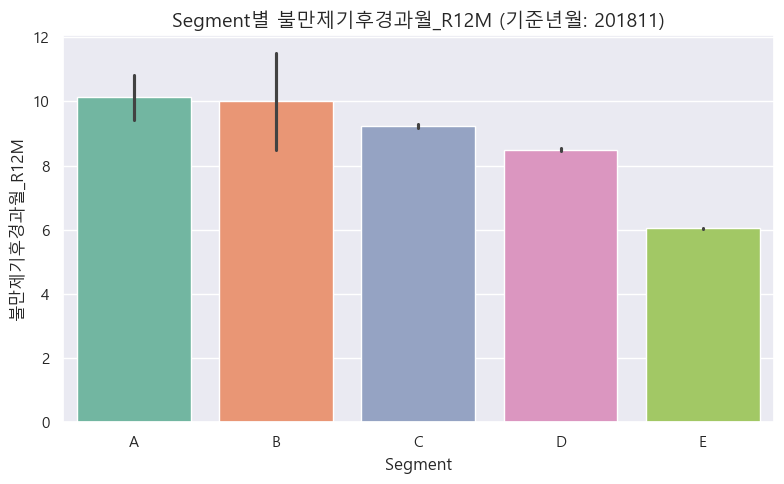

In [10]:
# 정렬 기준: 평균 청구금액 기준 내림차순
segment_order = (
    subset.groupby('Segment')['불만제기후경과월_R12M']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# 색상 팔레트
palette = sns.color_palette("Set2")

# 시각화
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=subset,
    x='Segment',
    y='불만제기후경과월_R12M',
    estimator='mean',
    order=segment_order,  # ✅ 정렬 반영
    palette=palette,
)

# 제목 및 축 설정
ax.set_title('Segment별 불만제기후경과월_R12M (기준년월: 201811)', fontsize=14)
ax.set_xlabel('Segment', fontsize=12)
ax.set_ylabel('불만제기후경과월_R12M', fontsize=12)

plt.tight_layout()
plt.show()


In [11]:
train_df.groupby('Segment')['불만제기후경과월_R12M'].mean()

Segment
A    10.148148
B    10.000000
C     9.237715
D     8.491144
E     6.041281
Name: 불만제기후경과월_R12M, dtype: float64

In [12]:
subset.groupby('Segment')['불만제기후경과월_R12M'].max()

Segment
A    12
B    12
C    12
D    12
E    12
Name: 불만제기후경과월_R12M, dtype: int64

### 방문후경과월_PC_R6M	

- 방문후경과월 PC웹 (최근6개월간)	int64	6, 0, 2, 3, 1	범주형

In [15]:
train_df['방문후경과월_PC_R6M'].value_counts()

방문후경과월_PC_R6M
6    2092569
0     182267
3      27879
4      27467
2      27325
5      26696
1      15797
Name: count, dtype: int64

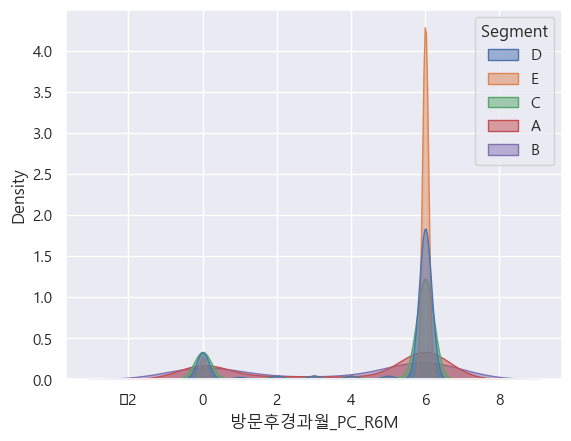

In [16]:
sns.kdeplot(
    data=train_df,
    x='방문후경과월_PC_R6M',
    hue='Segment',
    fill=True,
    common_norm=False,
    alpha=0.5
)
plt.show()

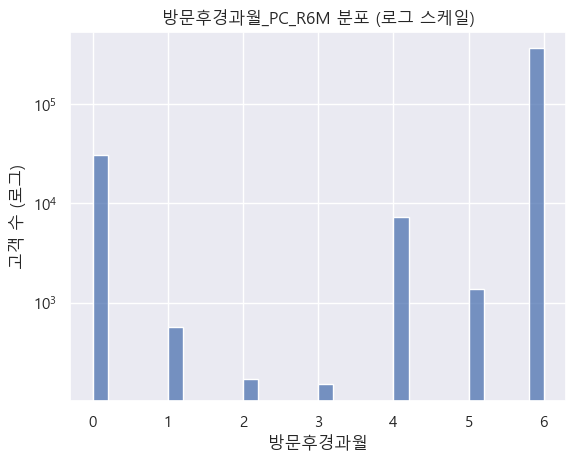

In [51]:
sns.histplot(subset['방문후경과월_PC_R6M'], bins=30)
plt.yscale('log')  # 로그 스케일 적용
plt.title('방문후경과월_PC_R6M 분포 (로그 스케일)')
plt.xlabel('방문후경과월')
plt.ylabel('고객 수 (로그)')
plt.show()


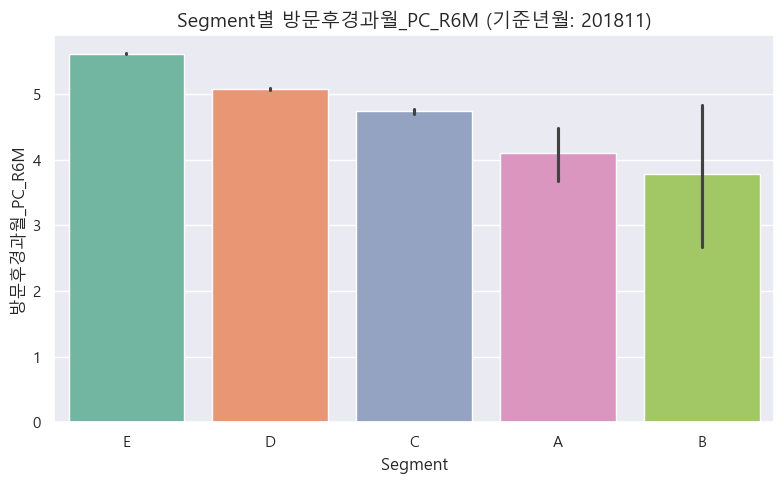

In [18]:
# Segment별 평균 '평잔_일시불_해외_6M' 기준으로 정렬
segment_order = (
    subset.groupby('Segment')['방문후경과월_PC_R6M']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# 색상 설정
palette = sns.color_palette("Set2")

# 시각화
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=subset,
    x='Segment',
    y='방문후경과월_PC_R6M',
    order=segment_order,  # ✅ 정렬 적용
    palette=palette,
)

# 제목 및 축 설정
ax.set_title('Segment별 방문후경과월_PC_R6M (기준년월: 201811)', fontsize=14)
ax.set_xlabel('Segment', fontsize=12)
ax.set_ylabel('방문후경과월_PC_R6M', fontsize=12)

plt.tight_layout()
plt.show()

In [19]:
train_df.groupby('Segment')['방문후경과월_PC_R6M'].mean()

Segment
A    3.812757
B    3.500000
C    4.556682
D    4.926103
E    5.539313
Name: 방문후경과월_PC_R6M, dtype: float64

### 홈페이지_금융건수_R6M	

- 홈페이지 금융건수 (최근6개월간)	int64	0, 11, 4, 3, 10	범주형

In [22]:
train_df['홈페이지_금융건수_R6M'].value_counts()

홈페이지_금융건수_R6M
0     2099135
6       66536
3       51356
4       42953
8       38373
5       31434
7       27193
9       14065
10      12535
2        5488
11       5440
12       3836
13       1170
14        420
15         37
1          29
Name: count, dtype: int64

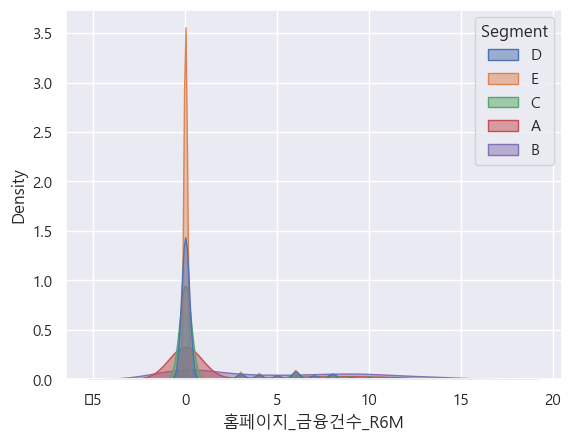

In [23]:
sns.kdeplot(
    data=train_df,
    x='홈페이지_금융건수_R6M',
    hue='Segment',
    fill=True,
    common_norm=False,
    alpha=0.5
)
plt.show()

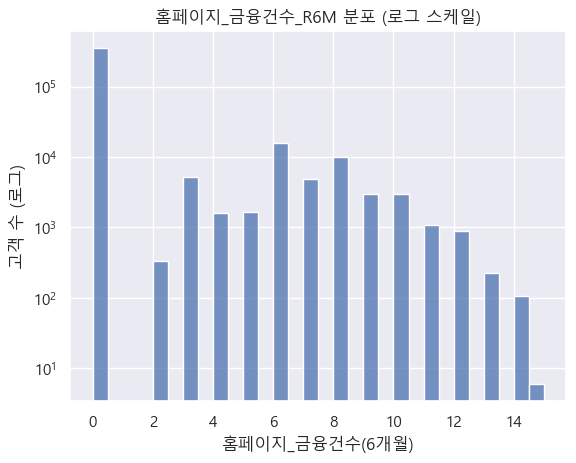

In [53]:
sns.histplot(subset['홈페이지_금융건수_R6M'], bins=30)
plt.yscale('log')  # y축 로그 스케일 적용
plt.title('홈페이지_금융건수_R6M 분포 (로그 스케일)')
plt.xlabel('홈페이지_금융건수(6개월)')
plt.ylabel('고객 수 (로그)')
plt.show()


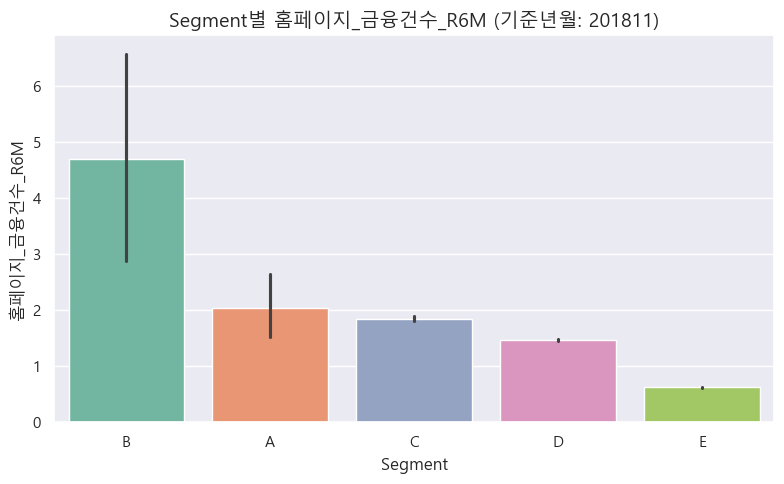

In [25]:
# Segment별 '평잔_일시불_6M' 평균 기준 내림차순 정렬
segment_order = (
    subset.groupby('Segment')['홈페이지_금융건수_R6M']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# 색상 설정
palette = sns.color_palette("Set2")  # 부드러운 파스텔 색상

# 시각화
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=subset,
    x='Segment',
    y='홈페이지_금융건수_R6M',
    order=segment_order,  # ✅ 정렬 적용
    palette=palette,
)

# 제목 및 축 설정
ax.set_title('Segment별 홈페이지_금융건수_R6M (기준년월: 201811)', fontsize=14)
ax.set_xlabel('Segment', fontsize=12)
ax.set_ylabel('홈페이지_금융건수_R6M', fontsize=12)

plt.tight_layout()
plt.show()